In [3]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
import pandas as pd

#https://www.geeksforgeeks.org/k-means-clustering-introduction/

from torch.profiler import profile, record_function, ProfilerActivity

In [2]:
colour = {
    'g': np.array([0, 158, 115])/256,
    'b': np.array([0, 114, 178])/256,
    'lb': np.array([86, 180, 233])/256,
    'r': np.array([213, 94, 0])/256,
    'o': np.array([230, 159, 0])/256,
    'y': np.array([240, 228, 66])/256,
    'p': np.array([204, 121, 167])/256,
    }

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Make Data

In [4]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

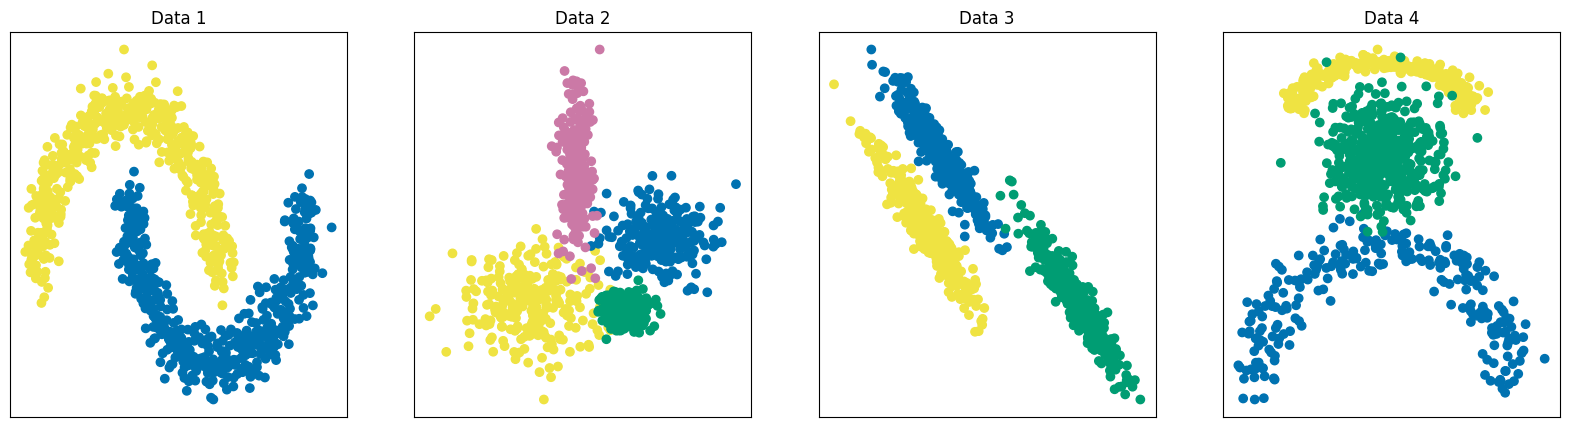

In [5]:
data1 = moons()
data2 = four_gaussians()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['b'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['g'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

## Euclidean Clustering

In [6]:
def distance_euclidean(x, y):
    return torch.sqrt(torch.sum((x-y)**2))

In [7]:
def k_means(data, k, distance, epochs=1000):
    n = data.shape[0]
    m = data.shape[1]
    centroids = np.random.rand(k, m)
    for _ in range(epochs):
        clusters = [[] for _ in range(k)]
        for i in range(n):
            distances = [distance(data[i], centroids[j]) for j in range(k)]
            clusters[np.argmin(distances)].append(i)
        for j in range(k):
            if len(clusters[j]) > 0:
                centroids[j] = torch.mean(data[clusters[j]], axis=0) # np.mean assumes euclidean geometry. LAMINAR is not applicable here
    return centroids, clusters

In [8]:
def transform_labels(labels):
    # labels is a list of lists with inices of points in the same cluster
    # transform into an array with the length of the higherst index found and assignt each index the cluster it is in
    n = max([max(cluster) for cluster in labels]) + 1
    transformed = np.zeros(n)
    for i, cluster in enumerate(labels):
        transformed[cluster] = i
    return transformed

## LAMINAR Clustering

In [9]:
def pairwise_distance(x, y, LAM):

    if LAM.save_distance_matrix:
        # y is a subset of LAM.data. Get the indices of the points in y in the LAM.data
        idx_y = [i for i in range(LAM.data.shape[0]) if LAM.data[i] in y]

        _, idx_x, dist_matrix, _ = LAM.check_expansion(x)

        # get entries of dist_matrix corresponding to every pait between x and y
        dist = dist_matrix[np.ix_(idx_x, idx_y)]
        return dist

    else:
        # y is a subset of LAM.data. Get the indices of the points in y in the LAM.data
        idx_y = [i for i in range(LAM.data.shape[0]) if LAM.data[i] in y]

        expanded_graph, idx_x, _, _ = LAM.check_expansion(x)

        # get entries of dist_matrix corresponding to every pait between x and y
        #dist = dist_matrix[np.ix_(idx_x, idx_y)]

        dist_array, _ = LAMINAR.utils.dijkstra.dijkstra(expanded_graph, idx_x, idx_y)

        dist = torch.tensor(np.array([dist_array])[0])
        return dist

In [10]:
def swarm(n_start, data, metric, LAM, n=15):
    # fit a gaussian to the data as floats
    mu = data.mean(axis=0).numpy()
    sigma = data.std(axis=0).numpy()

    # sample n_start points from the gaussian
    swarm = torch.Tensor(np.random.randn(n_start, 2) * sigma + mu)

    # sample a velocity for each start point
    swarm_velocity = torch.Tensor(np.random.randn(n_start, 2))

    # init
    best_dist = 999999
    best_point = None
    local_best_dist = torch.ones(n_start) * 99999
    local_best_point = swarm.clone()

    # arrays for plotting
    #array_of_swarm = []
#
    #array_of_inertia = []
    #array_of_global_best_vectors = []
    #array_of_personal_best_vectors = []
#
    #array_of_swarm_velocity = []
#
    #array_of_global_best_points = []

    
    for _ in range(n):
        # for each point in the swarm, calculate the distance to each point in the data set and sum it up
        #dist = torch.zeros(n_start, data.shape[0])
        #for i in range(n_start):
        #    dist[i] = metric(swarm[i], data)
        #dist = torch.sum(dist, dim=1)

        dist = metric(swarm, data, LAM)  # get the distance from every point in swarm to ever point in data, returning a matrix with shape (n_start, data.shape[0])
        dist = torch.sum(dist**2, dim=1) # KARCHER MEANS and FRECHET MEAN!

        # GLOBAL BEST
        # find the point with lowest distance and the respective distance
        iter_best_point = swarm[torch.argmin(dist)]
        iter_best_dist = torch.min(dist)

        # if iter best is better than best, update best
        if iter_best_dist < best_dist:
            best_dist = iter_best_dist
            best_point = iter_best_point

        # PERSONAL BEST
        # check for every point whether iter peronal best is better than personal best
        for i in range(n_start):
            if dist[i] < local_best_dist[i]:
                local_best_dist[i] = dist[i].clone()
                local_best_point[i] = swarm[i].clone()

        # update velocity
        
        # for each point, get the vector to the best point
        global_best = best_point - swarm
        personal_best = local_best_point - swarm
        inertia = swarm_velocity


        # update velocity
        swarm_velocity = (0.4*inertia + 0.3*global_best + 0.3*personal_best)

        # fill arrays
        #array_of_swarm.append(swarm.clone())
#
        #array_of_inertia.append(inertia.clone())
        #array_of_global_best_vectors.append(global_best.clone())
        #array_of_personal_best_vectors.append(personal_best.clone())
#
        #array_of_swarm_velocity.append(swarm_velocity.clone())
#
        #array_of_global_best_points.append(best_point.clone())

        
        # update swarm
        swarm += swarm_velocity
    #return array_of_swarm, array_of_inertia, array_of_global_best_vectors, array_of_personal_best_vectors, array_of_swarm_velocity, array_of_global_best_points, best_point 
    return best_point   

In [11]:
def k_means_LAM(data, k, LAM, epochs=1):
    n = data.shape[0]
    d = data.shape[1]
    # for centroids, take random datapoints from data
    #centroids = torch.rand(k, d)
    centroids = data[np.random.choice(n, k, replace=False)]

    for _ in range(epochs):
        # call query; return idx, the indices of the closest points in increasing order for the centroids, and dists, the distances of the respective point
        idx, dists = LAM.query(centroids)

        for i in range(len(idx)):
            # sort dists[k] according to idx[k], which also sort idx[k]
            sorted_idx = torch.argsort(idx[i])
            #idx[k] = idx[k][sorted_idx]
            dists[i] = dists[i][sorted_idx]

        #idx = idx[:, :n]
        dists = dists[:, :n]

        dists = dists.T
        #idx = idx.T

        # for each point, check which cluster it should be assigned to
        clusters = [[] for _ in range(k)]

        for i in range(n):
            # get argmin of dists[i]
            #print(dists[i])
            cluster = torch.argmin(dists[i]).item()
            #print(cluster)
            clusters[cluster].append(i)

        # update centroids
        for j in range(k):
            if len(clusters[j]) > 0:
                centroids[j] = swarm(50, data[clusters[j]], pairwise_distance, LAM, n=15)
                
    return centroids, clusters

In [12]:
from itertools import permutations

def calculate_min_error_rate(ground_truth, predicted):
    # Convert tensors to numpy arrays if needed
    if isinstance(ground_truth, torch.Tensor):
        ground_truth = ground_truth.numpy()
    if isinstance(predicted, torch.Tensor):
        predicted = predicted.numpy()

    gt_labels = np.unique(ground_truth)
    pred_labels = np.unique(predicted)

    min_error_rate = float('inf')

    for perm in permutations(pred_labels):
        # Only map as many predicted labels as there are ground truth labels
        label_mapping = {pred_label: gt_label for pred_label, gt_label in zip(perm, gt_labels)}

        # For predicted labels not in mapping, assign a dummy label (e.g., -1)
        mapped_predicted = np.array([label_mapping.get(pred_label, -1) for pred_label in predicted])

        error_rate = np.mean(mapped_predicted != ground_truth)

        if error_rate < min_error_rate:
            min_error_rate = error_rate

    return min_error_rate

In [13]:
import pandas as pd

# make pd dataframe for each dataset and store error rates
eucl_error_rates = pd.DataFrame({'Dataset': ['Moons', 'Four Gaussians', 'Streched Gaussians', 'Combined Structure']})
lam_error_rates = pd.DataFrame({'Dataset': ['Moons', 'Four Gaussians', 'Streched Gaussians', 'Combined Structure']})

for i in range(20):   
    print(f"Iteration {i+1}")
    # do clustering for all datasets with euclidean metric 
    LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=750, save_distance_matrix=False)
    LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=750, save_distance_matrix=False)
    LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=750, save_distance_matrix=False)
    LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=750, save_distance_matrix=False)

    # do clustering for all datasets with euclidean metric

    centroids1_euc, labels1_euc = k_means(data1[0], 2, distance_euclidean, 15)
    labels1_euc = transform_labels(labels1_euc)
    centroids2_euc, labels2_euc = k_means(data2[0], 4, distance_euclidean, 15)
    labels2_euc = transform_labels(labels2_euc)
    centroids3_euc, labels3_euc = k_means(data3[0], 3, distance_euclidean, 15)
    labels3_euc = transform_labels(labels3_euc)
    centroids4_euc, labels4_euc = k_means(data4[0], 3, distance_euclidean, 15)
    labels4_euc = transform_labels(labels4_euc)

    # calculate error rates
    error_rate1_euc = calculate_min_error_rate(data1[1], labels1_euc)
    error_rate2_euc = calculate_min_error_rate(data2[1], labels2_euc)
    error_rate3_euc = calculate_min_error_rate(data3[1], labels3_euc)
    error_rate4_euc = calculate_min_error_rate(data4[1], labels4_euc)

    # store error rates in dataframe
    eucl_error_rates[f'Iteration {i+1}'] = [error_rate1_euc, error_rate2_euc, error_rate3_euc, error_rate4_euc]

    ###
    # same with LAM

    centroids1_lam, labels1_lam = k_means_LAM(data1[0], 2, LAM1, epochs=10)
    labels1_lam = transform_labels(labels1_lam)
    centroids2_lam, labels2_lam = k_means_LAM(data2[0], 4, LAM2, epochs=10)
    labels2_lam = transform_labels(labels2_lam)
    centroids3_lam, labels3_lam = k_means_LAM(data3[0], 3, LAM3, epochs=10)
    labels3_lam = transform_labels(labels3_lam)
    centroids4_lam, labels4_lam = k_means_LAM(data4[0], 3, LAM4, epochs=10)
    labels4_lam = transform_labels(labels4_lam)

    # calculate error rates
    error_rate1_lam = calculate_min_error_rate(data1[1], labels1_lam)
    error_rate2_lam = calculate_min_error_rate(data2[1], labels2_lam)
    error_rate3_lam = calculate_min_error_rate(data3[1], labels3_lam)
    error_rate4_lam = calculate_min_error_rate(data4[1], labels4_lam)

    # store error rates in dataframe
    lam_error_rates[f'Iteration {i+1}'] = [error_rate1_lam, error_rate2_lam, error_rate3_lam, error_rate4_lam]


    # save the dataframe
    eucl_error_rates.to_csv('euclidean_error_rates.csv', index=False)
    lam_error_rates.to_csv('lam_error_rates.csv', index=False)

Iteration 1
Iteration 0 | Train Loss: 1356.3387451171875 | Validation Loss: 1872.0911865234375
Iteration 99 | Train Loss: 270.78302001953125 | Validation Loss: 279.31610107421875
Iteration 199 | Train Loss: 258.61328125 | Validation Loss: 255.48741149902344
Iteration 299 | Train Loss: 251.6210479736328 | Validation Loss: 260.1385803222656
Iteration 399 | Train Loss: 233.6065673828125 | Validation Loss: 234.2351531982422
Iteration 499 | Train Loss: 227.90296936035156 | Validation Loss: 232.6278839111328
Iteration 599 | Train Loss: 224.91073608398438 | Validation Loss: 230.18624877929688
Iteration 699 | Train Loss: 224.31777954101562 | Validation Loss: 230.134765625
Iteration 0 | Train Loss: 1185.5003662109375 | Validation Loss: 1746.4078369140625
Iteration 99 | Train Loss: 265.3386535644531 | Validation Loss: 278.2201843261719
Iteration 199 | Train Loss: 197.07916259765625 | Validation Loss: 223.2536163330078
Iteration 299 | Train Loss: 197.3762664794922 | Validation Loss: 221.426300048

In [14]:
# calculate mean and variance of the rows, ignoring th efirst entry
eucl_error_rates_mean = eucl_error_rates.iloc[:, 1:].mean(axis=1)
eucl_error_rates_var = eucl_error_rates.iloc[:, 1:].var(axis=1)

lam_error_rates_mean = lam_error_rates.iloc[:, 1:].mean(axis=1)
lam_error_rates_var = lam_error_rates.iloc[:, 1:].var(axis=1)

# print
print("Euclidean Error Rates Mean:")
print(eucl_error_rates_mean)
print("Euclidean Error Rates Variance:")
print(eucl_error_rates_var)
print("LAM Error Rates Mean:")
print(lam_error_rates_mean)
print("LAM Error Rates Variance:")
print(lam_error_rates_var)

Euclidean Error Rates Mean:
0    0.15255
1    0.08075
2    0.17555
3    0.38155
dtype: float64
Euclidean Error Rates Variance:
0    2.605263e-07
1    9.844829e-03
2    3.734211e-06
3    7.468158e-05
dtype: float64
LAM Error Rates Mean:
0    0.07685
1    0.18150
2    0.10340
3    0.23480
dtype: float64
LAM Error Rates Variance:
0    0.000334
1    0.032909
2    0.036529
3    0.014629
dtype: float64


In [4]:
# load and print the dataframes
eucl_error_rates = pd.read_csv('euclidean_error_rates.csv')
lam_error_rates = pd.read_csv('lam_error_rates.csv')

In [5]:
print(eucl_error_rates)

              Dataset  Iteration 1  Iteration 2  Iteration 3  Iteration 4  \
0               Moons        0.153        0.153        0.153        0.153   
1      Four Gaussians        0.048        0.048        0.049        0.049   
2  Streched Gaussians        0.177        0.173        0.177        0.173   
3  Combined Structure        0.385        0.387        0.386        0.387   

   Iteration 5  Iteration 6  Iteration 7  Iteration 8  Iteration 9  ...  \
0        0.152        0.152        0.152        0.153        0.153  ...   
1        0.048        0.049        0.049        0.049        0.048  ...   
2        0.177        0.173        0.176        0.173        0.173  ...   
3        0.366        0.385        0.387        0.386        0.387  ...   

   Iteration 11  Iteration 12  Iteration 13  Iteration 14  Iteration 15  \
0         0.152         0.153         0.152         0.152         0.152   
1         0.048         0.048         0.048         0.048         0.386   
2         0.1

In [6]:
print(lam_error_rates)

              Dataset  Iteration 1  Iteration 2  Iteration 3  Iteration 4  \
0               Moons        0.114        0.060        0.094        0.096   
1      Four Gaussians        0.332        0.043        0.035        0.378   
2  Streched Gaussians        0.007        0.498        0.007        0.494   
3  Combined Structure        0.225        0.178        0.148        0.368   

   Iteration 5  Iteration 6  Iteration 7  Iteration 8  Iteration 9  ...  \
0        0.073        0.097        0.058        0.077        0.079  ...   
1        0.050        0.044        0.046        0.625        0.342  ...   
2        0.006        0.009        0.005        0.007        0.007  ...   
3        0.381        0.375        0.170        0.033        0.418  ...   

   Iteration 11  Iteration 12  Iteration 13  Iteration 14  Iteration 15  \
0         0.092         0.062         0.058         0.042         0.075   
1         0.039         0.361         0.343         0.038         0.351   
2         0.0